In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import DBSCAN, OPTICS
import pandas as pd
from scipy.ndimage import sobel, uniform_filter1d
import scipy
import xarray as xr

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_64196/378018370.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [60]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
mission_32 = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
mission_31 = 'ArgusFF_20211013T163100Z_RectifiedVideo.avi'


In [61]:
def make_timetack(dir, file, stop=np.inf):
    cap = cv2.VideoCapture(os.path.join(dir, file))
    N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

    # NOTE: We're downsampling in along-shore to 10m
    skip = 1
    timestack = np.zeros((min(N, stop), H//skip, W))
    # stop = 300
    # stop = np.inf

    for i in tqdm(range(min(N, stop))):
        _, frame = cap.read()
        timestack[i] = frame[::skip, :, 0]

    cap.release()
    cv2.destroyAllWindows()
    return timestack

In [62]:
file = mission_32

timestack = make_timetack(dir, file, 500)

cap = cv2.VideoCapture(os.path.join(dir, file))

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = 2
SECONDS = 100
NFRAMES = FPS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:00<00:00, 524.49it/s]


In [128]:
def plot_timestack(timestack, peaks, time=(0, -1), along_shore=500):
    times = np.arange(timestack.shape[0])[time[0]: time[1]]
    plt.imshow(timestack[times, along_shore, :].T)
    
    for i in range(peaks.shape[1]):
        plt.scatter(times, peaks[along_shore, i, times], c=np.zeros_like(times) + i/peaks.shape[1], s=4, cmap='jet', vmin=0, vmax=1, alpha=0.75)
    plt.colorbar()

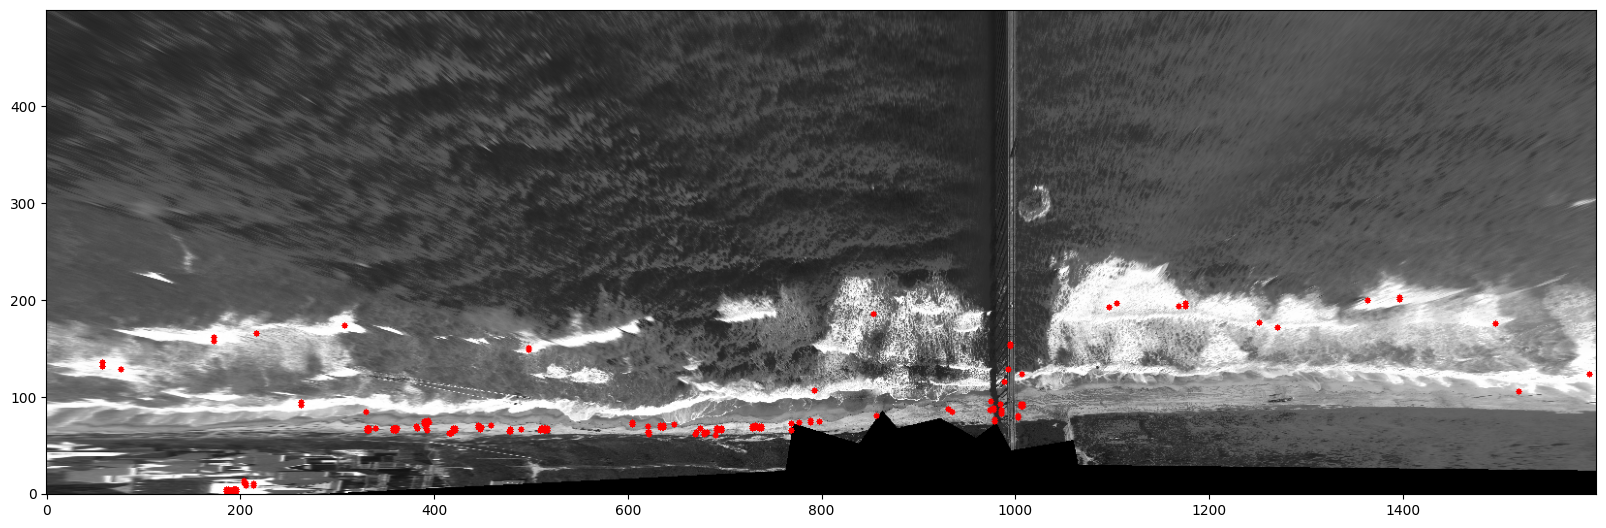

In [129]:
def draw_peaks(image, peaks):
    image = cv2.merge((image, image, image))
 
    for i in range(peaks.shape[1]):
        for x, y, in zip(peaks[:, i], np.arange(peaks.shape[0])):
            if x == -1:
                continue
            # image = cv2.circle(image, (x, y), int((peaks.shape[1] - c + 1)//2), (255, 0, c * 25), -1)
            image = cv2.circle(image, (x, y), 3, (255, 0, 0), -1)

    return image.astype(np.uint8)

plt.figure(figsize=(20, 7))
plt.imshow(np.swapaxes(draw_peaks(timestack[0].astype(np.uint8), filtered_peaks[:, :5, 0]), 0, 1))

In [141]:
# Peak Finder Approach
c=10
peaks = []
for i in tqdm(range(0, timestack.shape[1])):
    sb = sobel(timestack[:, i, :])
    p = []

    for j in range(0, sb.shape[0]):

        pks, props = scipy.signal.find_peaks(
                            sb[j, :],
                        )
    
        peaks_sorted_by_brightness = pks[np.argsort(timestack[j, i, :][pks])[::-1]]
        if(len(pks)>=c):
            p.append(peaks_sorted_by_brightness[:c])

        else:
            # Fill any missing peaks with -1 for consistent dimensions
            p.append(np.concatenate([peaks_sorted_by_brightness, [-1]*int(c-len(pks))]))

    peaks.append(
            np.array(p).T
        )
    
peaks = np.array(peaks)
peaks.shape


100%|██████████| 1600/1600 [00:12<00:00, 124.63it/s]


(1600, 10, 500)

In [130]:
# Original Approach
c=10
peaks = []
for i in tqdm(range(0, timestack.shape[1])):
    surf_zone_min = 65
    surf_zone_max = 300
    p = np.argsort(sobel(timestack[:, i, surf_zone_min:surf_zone_max].T), axis=0)[::-1]
    peaks.append(p+surf_zone_min)

peaks = np.array(peaks)
peaks.shape

100%|██████████| 1600/1600 [00:07<00:00, 215.82it/s]


(1600, 235, 500)

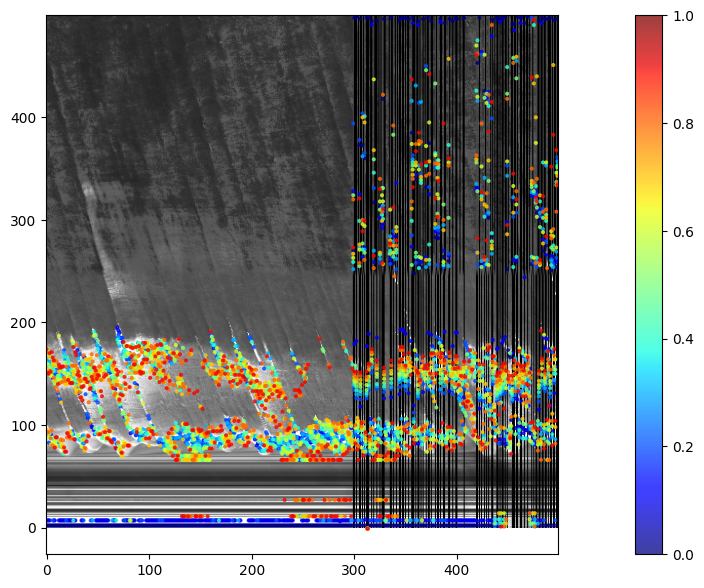

In [142]:
plt.figure(figsize=(20, 7))
plot_timestack(timestack, peaks[:, :10, :], (0, -1), 200)

In [121]:
c = 10
labels = []
filtered_peaks = []
for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
    X = np.array([np.array([np.arange(timestack.shape[0])]*c).flatten(), peaks[i][:c].flatten()])
    clustering = DBSCAN(eps=3, min_samples=5).fit(X.T)
    l = clustering.labels_
    l = l.reshape(c, -1)
    filtered_peaks.append(peaks[i][:c])
    filtered_peaks[-1][l<0] = -1
    l = clustering.labels_
    labels.append(l[l>=0])
    
filtered_peaks = np.array(filtered_peaks)
filtered_peaks.shape

100%|██████████| 1600/1600 [00:28<00:00, 56.56it/s]


(1600, 10, 500)

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_64196/2104720869.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(count.T/seconds_of_footage.T, vmax=0.1)
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_64196/2104720869.py:3: RuntimeWarning: invalid value encountered in divide
  plt.imshow(count.T/seconds_of_footage.T, vmax=0.1)


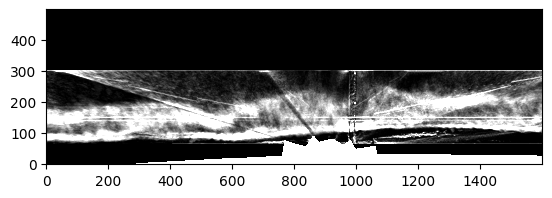

In [139]:
count = new_pipeline.count_peaks(peaks[:, :5, :], timestack.shape[1:])
seconds_of_footage = (timestack !=0).sum(0)/FPS
plt.imshow(count.T/seconds_of_footage.T, vmax=0.1)

In [135]:
fname = 'peaks.mp4'
out = cv2.VideoWriter(fname, cv2.VideoWriter_fourcc(*'avc1'), FPS*5, (H,W))
c=10
for i, (frame, peak) in tqdm(enumerate(zip(timestack, peaks[:, :c, :].T))):
    f = np.flip(np.swapaxes(draw_peaks(frame, peak.T), 0, 1), 0)
    out.write(f)
        
out.release()
cv2.destroyAllWindows()


500it [00:12, 41.01it/s]


100%|██████████| 1600/1600 [00:18<00:00, 87.07it/s]
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_64196/1963714454.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(*filtered_peaks[i][:, labels[i]==j], c=v[j])


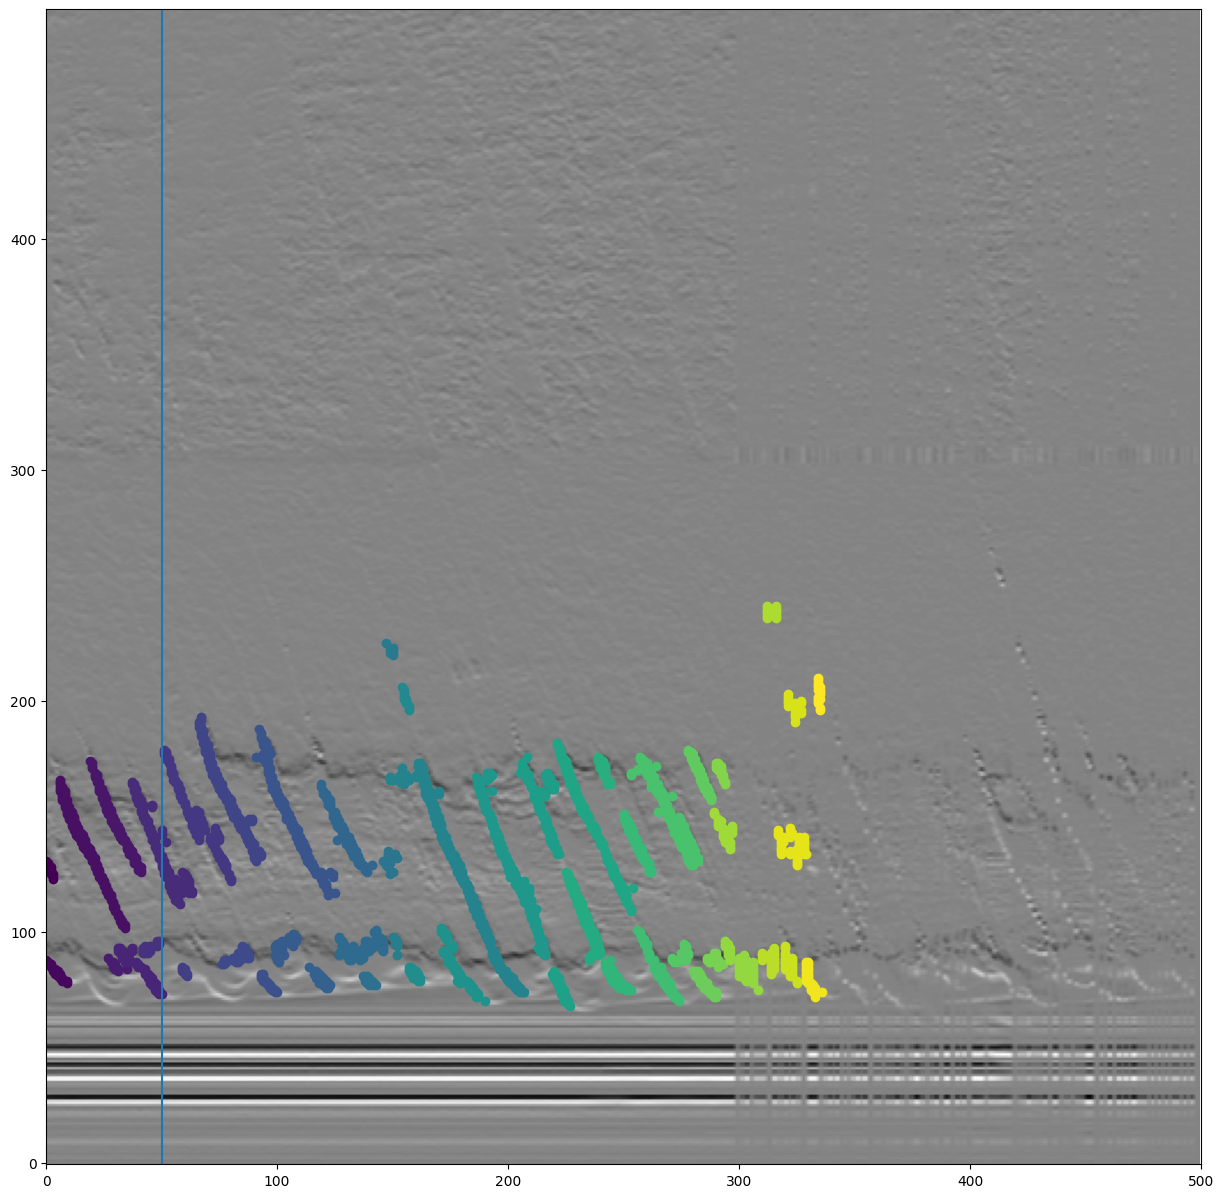

In [143]:
peaks = []
for i in tqdm(range(0, timestack.shape[1])):
    surf_zone_min = 65
    surf_zone_max = 275
    p = np.argsort(sobel(timestack[:, i, surf_zone_min:surf_zone_max].T), axis=0)[::-1]
    peaks.append(p+surf_zone_min)

# DBSCAN to get rid of random points

# This needs some work. I feel like I should be able to get the full wave coming to shore in one piecem at least for some of these. And then maybe merge them w/ ransac?
c = 10
labels = []
filtered_peaks = []
for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
    X = np.array([np.array([np.arange(timestack.shape[0])]*c).flatten(), peaks[i][:c].flatten()])
    clustering = DBSCAN(eps=4, min_samples=7).fit(X.T)
    l = clustering.labels_
    filtered_peaks.append(X[:, l>=0])
    labels.append(l[l>=0])
    
i = 10
plt.figure(figsize=(15, 15))
plt.imshow(sobel(timestack[:, i, :]).T)
N = 50
v= plt.get_cmap('viridis', N)(np.arange(N))
for j in range(N):
    plt.scatter(*filtered_peaks[i][:, labels[i]==j], c=v[j])
    # plt.scatter(*X[:, labels==1], c='g', alpha=0.5)
plt.xlim(0, 500)
plt.axvline(50)